# Taller: Diseño y Evaluación de Técnicas de Machine Learning

**Curso:** Técnicas de Inteligencia Artificial  
**Universidad Nacional de Colombia — Sede Bogotá**  
**Ingeniería Mecatrónica — Facultad de Ingeniería**  
**Profesor:** Flavio Prieto — faprietoo@unal.edu.co  
**Estudiantes:** Sergio Andrés Bolaños Penagos, Jorge Nicolas Garzon Acevedo, David Santiago Pirateque Suarez  
**Fecha:** Abril 2026

---

## Objetivo

Resolver el mismo problema de clasificación multiclase abordado en el taller de Redes Neuronales Artificiales, usando técnicas clásicas de Machine Learning sobre el dataset **Olivetti Faces**.

El modelo de referencia del taller anterior es un MLP completamente denso. En este taller se implementan y optimizan dos modelos clásicos supervisados:

1. **Máquinas de Vectores de Soporte (SVM)**, evaluando kernel lineal y kernel RBF.
2. **Random Forest**, como ensamble clásico de árboles de decisión.

La comparación se realiza con el mismo conjunto de entrenamiento, el mismo conjunto de validación y las mismas características de entrada: imágenes de 64 × 64 píxeles aplanadas en vectores de 4096 características.

---
## 1. Librerías y configuración general

Se importan las librerías usadas en el notebook de aprendizaje supervisado para clasificación: `SVC`, `RandomForestClassifier`, `train_test_split`, métricas de clasificación y herramientas de visualización.

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

print(f"Semilla de reproducibilidad: {SEED}")

Semilla de reproducibilidad: 42


---
## 2. Modelo de referencia del taller RNA

El taller de Redes Neuronales Artificiales entrenó un MLP profundo sobre el mismo dataset. Ese resultado se usa como línea base para comparar los modelos clásicos.

El mejor modelo reportado en el taller RNA fue:

| Modelo | Entrada | Capas ocultas | Validación | Test | F1 macro | Comentario |
|---|---:|---|---:|---:|---:|---|
| MLP | 4096 | 512-256 | 0.9875 | 0.9750 | 0.9733 | Red densa con regularización |

In [2]:
mlp_reference = {
    "Modelo": "MLP RNA",
    "Familia": "Deep Learning",
    "Entrada": 4096,
    "Hiperparámetros": "hidden=[512, 256], Adam, Dropout=0.40, L2=1e-5",
    "Train Accuracy": 1.0000,
    "Val Accuracy": 0.9875,
    "Test Accuracy": 0.9750,
    "Precision Macro": 0.9833,
    "Recall Macro": 0.9750,
    "F1 Macro": 0.9733,
    "F1 Micro": 0.9750,
    "Tiempo (s)": 15.3,
    "Parámetros/Árboles": "2,240,808 parámetros",
}

pd.DataFrame([mlp_reference])

,Modelo,Familia,Entrada,Hiperparámetros,Train Accuracy,Val Accuracy,Test Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Micro,Tiempo (s),Parámetros/Árboles
0,MLP RNA,Deep Learning,4096,"hidden=[512, 256], Adam, Dropout=0.40, L2=1e-5",1.0,0.9875,0.975,0.9833,0.975,0.9733,0.975,15.3,"2,240,808 parámetros"


---
## 3. Carga y exploración del dataset Olivetti Faces

El dataset se carga con `fetch_olivetti_faces`, igual que en el taller RNA. Cada imagen en escala de grises tiene tamaño 64 × 64, por lo que cada muestra se representa como un vector de 4096 características.

Dimensiones de X: (400, 4096)
Número de clases: 40
Imágenes por clase: 10
Rango de intensidad: [0.00, 1.00]


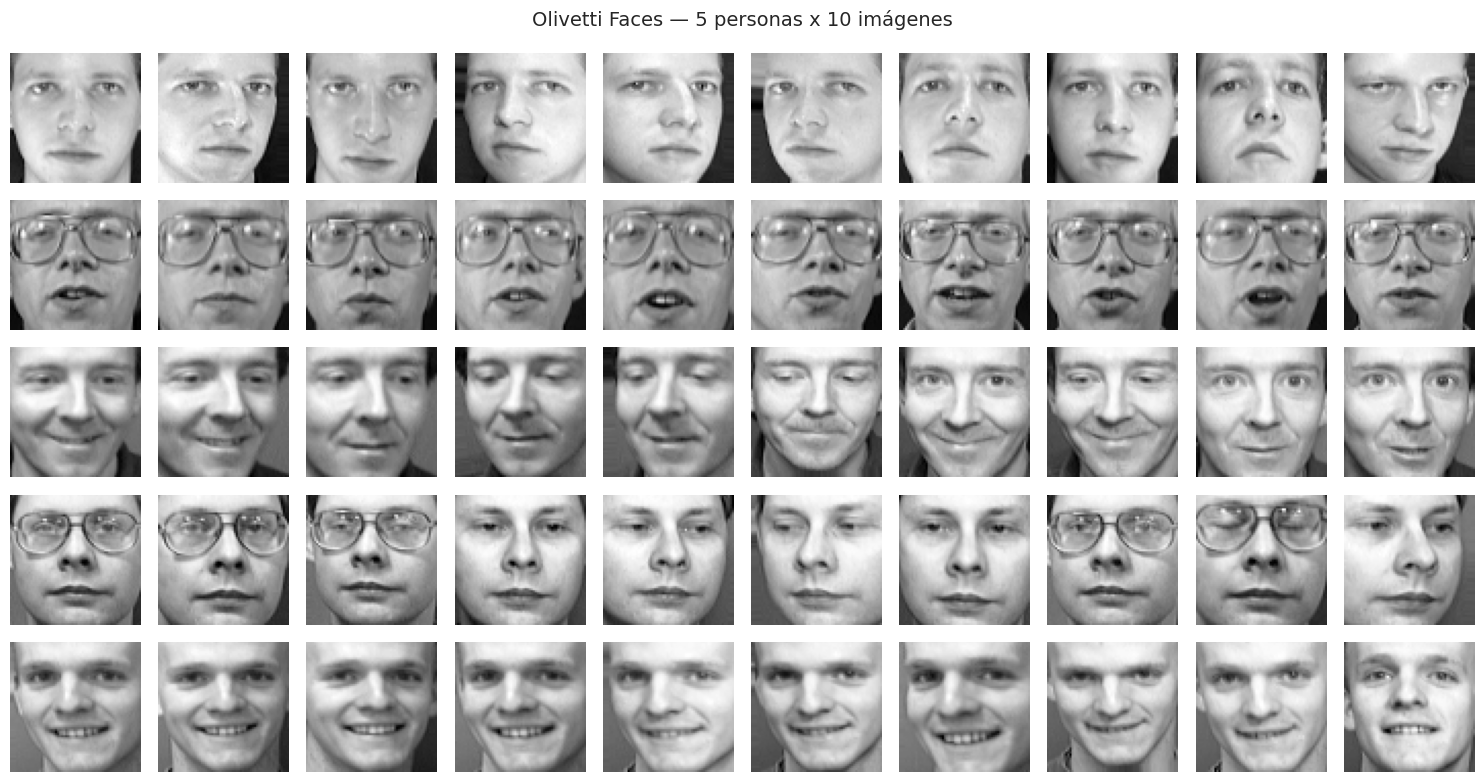

In [3]:
faces = fetch_olivetti_faces(shuffle=False)
X, y = faces.data, faces.target
images = faces.images

print(f"Dimensiones de X: {X.shape}")
print(f"Número de clases: {len(np.unique(y))}")
print(f"Imágenes por clase: {np.bincount(y)[0]}")
print(f"Rango de intensidad: [{X.min():.2f}, {X.max():.2f}]")

fig, axes = plt.subplots(5, 10, figsize=(15, 8))
fig.suptitle("Olivetti Faces — 5 personas x 10 imágenes", fontsize=14)

for persona in range(5):
    idxs = np.where(y == persona)[0]
    for j, idx in enumerate(idxs):
        axes[persona, j].imshow(images[idx], cmap="gray")
        axes[persona, j].axis("off")
        if j == 0:
            axes[persona, j].set_ylabel(f"P{persona}", fontsize=10)

plt.tight_layout()
plt.savefig("fig_ml_01_faces_grid.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.1 Distribución de clases

El conjunto tiene 40 clases y 10 imágenes por persona. Esto permite usar partición estratificada para conservar la misma proporción de clases en entrenamiento, validación y prueba.

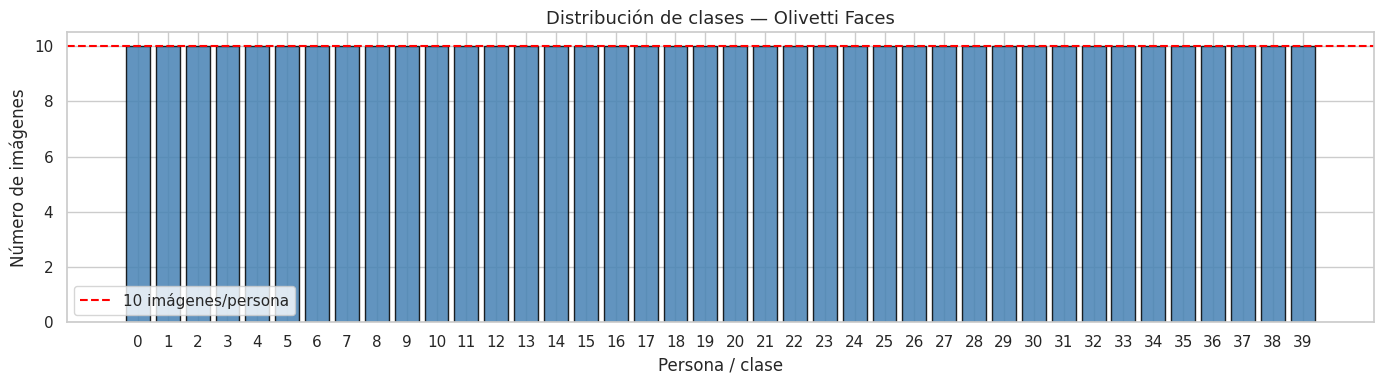

Dataset perfectamente balanceado: True


In [4]:
counts = np.bincount(y, minlength=40)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(40), counts, color="steelblue", edgecolor="black", alpha=0.85)
ax.axhline(10, color="red", linestyle="--", label="10 imágenes/persona")
ax.set_title("Distribución de clases — Olivetti Faces")
ax.set_xlabel("Persona / clase")
ax.set_ylabel("Número de imágenes")
ax.set_xticks(range(40))
ax.legend()
plt.tight_layout()
plt.savefig("fig_ml_02_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Dataset perfectamente balanceado: {bool(np.all(counts == 10))}")

---
## 4. Partición y normalización

Se conserva la misma estrategia del taller RNA: hold-out estratificado 60/20/20.

| Subconjunto | Proporción | Uso |
|---|---:|---|
| Entrenamiento | 60% | Ajustar los modelos clásicos |
| Validación | 20% | Seleccionar hiperparámetros |
| Prueba | 20% | Evaluación final después de seleccionar modelos |

La normalización se ajusta únicamente con el conjunto de entrenamiento para evitar fuga de información hacia validación o prueba.

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp,
)

print("Partición hold-out estratificada 60/20/20:")
for name, labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    c = np.bincount(labels, minlength=40)
    print(
        f"  {name:5s}: {len(labels):3d} muestras "
        f"({len(labels) / len(y) * 100:.0f}%) — imgs/persona: [{c.min()}, {c.max()}]"
    )

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

print("\nDimensionalidad usada por todos los modelos clásicos:")
print(f"  X_train_sc: {X_train_sc.shape}")
print(f"  X_val_sc:   {X_val_sc.shape}")
print(f"  X_test_sc:  {X_test_sc.shape}")
print(f"  Ratio muestras/features en train: {X_train_sc.shape[0] / X_train_sc.shape[1]:.4f}")

Partición hold-out estratificada 60/20/20:
  Train: 240 muestras (60%) — imgs/persona: [6, 6]
  Val  :  80 muestras (20%) — imgs/persona: [2, 2]
  Test :  80 muestras (20%) — imgs/persona: [2, 2]

Dimensionalidad usada por todos los modelos clásicos:
  X_train_sc: (240, 4096)
  X_val_sc:   (80, 4096)
  X_test_sc:  (80, 4096)
  Ratio muestras/features en train: 0.0586


---
## 5. Funciones comunes de entrenamiento, búsqueda y evaluación

Los dos modelos se ajustan con búsqueda manual sobre el conjunto de validación. Esto permite cumplir la condición del taller: todos los modelos se comparan usando el mismo conjunto de entrenamiento, las mismas características y la misma validación.

In [6]:
def summarize_metrics(model, X_train, y_train, X_val, y_val, X_test, y_test):
    """Calcula métricas principales en train, validación y test."""
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    return {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Val Accuracy": accuracy_score(y_val, y_val_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision Macro": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1 Micro": f1_score(y_test, y_test_pred, average="micro", zero_division=0),
    }


def search_model(model_name, build_model, param_grid, X_train, y_train, X_val, y_val):
    """Evalúa combinaciones de hiperparámetros y ordena por accuracy/F1 de validación."""
    rows = []
    grids = list(ParameterGrid(param_grid))
    print(f"{model_name}: {len(grids)} combinaciones de hiperparámetros")

    for i, params in enumerate(grids, start=1):
        model = build_model(params)
        start = time.time()
        model.fit(X_train, y_train)
        fit_time = time.time() - start

        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        rows.append({
            "Modelo": model_name,
            "Trial": i,
            "Train Accuracy": accuracy_score(y_train, y_train_pred),
            "Val Accuracy": accuracy_score(y_val, y_val_pred),
            "Val F1 Macro": f1_score(y_val, y_val_pred, average="macro", zero_division=0),
            "Tiempo fit (s)": fit_time,
            "params": params,
        })

    results = pd.DataFrame(rows)
    results = results.sort_values(
        ["Val Accuracy", "Val F1 Macro", "Tiempo fit (s)"],
        ascending=[False, False, True],
    ).reset_index(drop=True)
    return results


def train_best_model(model_name, build_model, search_results, X_train, y_train):
    """Reentrena el mejor modelo de una familia usando solo el conjunto de entrenamiento."""
    best_params = search_results.loc[0, "params"]
    model = build_model(best_params)
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    return model, best_params, elapsed


def format_params(params):
    """Convierte diccionarios de hiperparámetros en texto corto para tablas."""
    return ", ".join(f"{k}={v}" for k, v in params.items())

---
## 6. Modelo clásico 1: SVM

Las Máquinas de Vectores de Soporte buscan una frontera de decisión que maximice el margen. En el material de clase se revisan dos ideas importantes para este taller:

- El hiperparámetro `C`, que controla el balance entre margen amplio y penalización de errores.
- El uso de kernels, especialmente el kernel RBF, para modelar fronteras no lineales.

En este experimento se comparan SVM lineal y SVM con kernel RBF dentro de la misma búsqueda de hiperparámetros.

In [7]:
def build_svm(params):
    return SVC(**params)

svm_param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 0.3, 1, 3, 10, 30, 100],
        "gamma": ["scale", 0.0001, 0.0003, 0.001, 0.003, 0.01],
    },
]

svm_search = search_model(
    "SVM",
    build_svm,
    svm_param_grid,
    X_train_sc,
    y_train,
    X_val_sc,
    y_val,
)

print("Top 10 configuraciones SVM por validación:")
display(svm_search.head(10))

SVM: 51 combinaciones de hiperparámetros


Top 10 configuraciones SVM por validación:


,Modelo,Trial,Train Accuracy,Val Accuracy,Val F1 Macro,Tiempo fit (s),params
0,SVM,2,1.0,0.9625,0.96,0.085061,"{'C': 0.003, 'kernel': 'linear'}"
1,SVM,1,1.0,0.9625,0.96,0.086099,"{'C': 0.001, 'kernel': 'linear'}"
2,SVM,3,1.0,0.9625,0.96,0.087709,"{'C': 0.01, 'kernel': 'linear'}"
3,SVM,9,1.0,0.9625,0.96,0.091327,"{'C': 10, 'kernel': 'linear'}"
4,SVM,35,1.0,0.9625,0.96,0.091927,"{'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}"
5,SVM,47,1.0,0.9625,0.96,0.094635,"{'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}"
6,SVM,8,1.0,0.9625,0.96,0.094664,"{'C': 3, 'kernel': 'linear'}"
7,SVM,30,1.0,0.9625,0.96,0.096982,"{'C': 3, 'gamma': 0.0003, 'kernel': 'rbf'}"
8,SVM,48,1.0,0.9625,0.96,0.097016,"{'C': 100, 'gamma': 0.0003, 'kernel': 'rbf'}"
9,SVM,5,1.0,0.9625,0.96,0.097377,"{'C': 0.1, 'kernel': 'linear'}"


Resumen por kernel:


Val Accuracy                     Val F1 Macro                      \
                max      mean       std          max      mean       std   
kernel                                                                     
linear       0.9625  0.962500  0.000000         0.96  0.960000  0.000000   
rbf          0.9625  0.736607  0.256269         0.96  0.755287  0.227157   

       Train Accuracy                     
                  max      mean      std  
kernel                                    
linear            1.0  1.000000  0.00000  
rbf               1.0  0.996627  0.01183

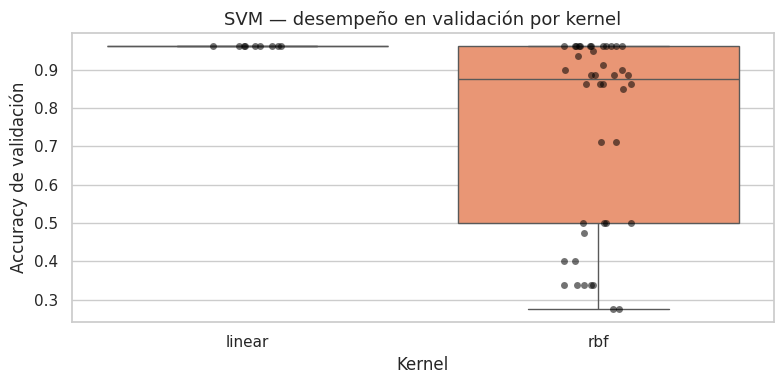

In [8]:
svm_by_kernel = (
    svm_search
    .assign(kernel=svm_search["params"].apply(lambda p: p["kernel"]))
    .groupby("kernel")[["Val Accuracy", "Val F1 Macro", "Train Accuracy"]]
    .agg(["max", "mean", "std"])
)

print("Resumen por kernel:")
display(svm_by_kernel)

fig, ax = plt.subplots(figsize=(8, 4))
plot_data = svm_search.assign(kernel=svm_search["params"].apply(lambda p: p["kernel"]))
sns.boxplot(data=plot_data, x="kernel", y="Val Accuracy", ax=ax, palette="Set2")
sns.stripplot(data=plot_data, x="kernel", y="Val Accuracy", ax=ax, color="black", alpha=0.55)
ax.set_title("SVM — desempeño en validación por kernel")
ax.set_xlabel("Kernel")
ax.set_ylabel("Accuracy de validación")
plt.tight_layout()
plt.savefig("fig_ml_03_svm_kernel_validation.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Modelo clásico 2: Random Forest

Random Forest combina múltiples árboles de decisión entrenados con muestreo bootstrap y selección aleatoria de características. Según el material de clase, este ensamble reduce el sobreajuste de un único árbol y permite estimar importancia de características.

En imágenes aplanadas, cada característica corresponde a un píxel. Por esta razón, la importancia del modelo puede visualizarse como un mapa 64 × 64.

In [9]:
def build_random_forest(params):
    return RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1,
        **params,
    )

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 20],
    "max_features": ["sqrt", 0.2],
    "min_samples_leaf": [1, 2],
}

rf_search = search_model(
    "Random Forest",
    build_random_forest,
    rf_param_grid,
    X_train_sc,
    y_train,
    X_val_sc,
    y_val,
)

print("Top 10 configuraciones Random Forest por validación:")
display(rf_search.head(10))

Random Forest: 24 combinaciones de hiperparámetros


Top 10 configuraciones Random Forest por validación:


,Modelo,Trial,Train Accuracy,Val Accuracy,Val F1 Macro,Tiempo fit (s),params
0,Random Forest,2,1.0,0.9500,0.948333,0.452017,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
1,Random Forest,4,1.0,0.9375,0.936667,0.334162,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
2,Random Forest,15,1.0,0.9375,0.936667,0.614795,"{'max_depth': 20, 'max_features': 'sqrt', 'min..."
3,Random Forest,3,1.0,0.9375,0.936667,0.621995,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
4,Random Forest,1,1.0,0.9375,0.935000,0.304651,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
5,Random Forest,5,1.0,0.9250,0.925952,0.553202,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
6,Random Forest,6,1.0,0.9250,0.923333,0.585529,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
7,Random Forest,14,1.0,0.9125,0.910833,0.388979,"{'max_depth': 20, 'max_features': 'sqrt', 'min..."
8,Random Forest,18,1.0,0.9125,0.910833,0.628644,"{'max_depth': 20, 'max_features': 'sqrt', 'min..."
9,Random Forest,16,1.0,0.9000,0.900952,0.224102,"{'max_depth': 20, 'max_features': 'sqrt', 'min..."


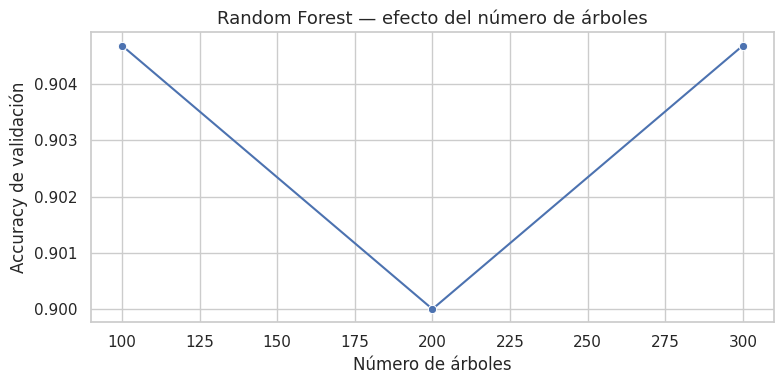

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
rf_plot = rf_search.copy()
rf_plot["n_estimators"] = rf_plot["params"].apply(lambda p: p["n_estimators"])
sns.lineplot(data=rf_plot, x="n_estimators", y="Val Accuracy", marker="o", errorbar=None, ax=ax)
ax.set_title("Random Forest — efecto del número de árboles")
ax.set_xlabel("Número de árboles")
ax.set_ylabel("Accuracy de validación")
plt.tight_layout()
plt.savefig("fig_ml_04_rf_estimators_validation.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Selección de mejores modelos por validación

Después de la búsqueda, se selecciona la mejor configuración de cada familia usando únicamente el conjunto de validación. Luego se evalúa cada modelo seleccionado en el conjunto de prueba.

In [11]:
svm_model, svm_best_params, svm_fit_time = train_best_model(
    "SVM",
    build_svm,
    svm_search,
    X_train_sc,
    y_train,
)

rf_model, rf_best_params, rf_fit_time = train_best_model(
    "Random Forest",
    build_random_forest,
    rf_search,
    X_train_sc,
    y_train,
)

classic_models = [
    {
        "Modelo": "SVM",
        "Familia": "ML clásico",
        "Entrada": X_train_sc.shape[1],
        "model": svm_model,
        "best_params": svm_best_params,
        "fit_time": svm_fit_time,
        "Parámetros/Árboles": "vectores de soporte",
    },
    {
        "Modelo": "Random Forest",
        "Familia": "ML clásico",
        "Entrada": X_train_sc.shape[1],
        "model": rf_model,
        "best_params": rf_best_params,
        "fit_time": rf_fit_time,
        "Parámetros/Árboles": f"{rf_best_params['n_estimators']} árboles",
    },
]

for item in classic_models:
    metrics = summarize_metrics(
        item["model"],
        X_train_sc,
        y_train,
        X_val_sc,
        y_val,
        X_test_sc,
        y_test,
    )
    item.update(metrics)
    item["Tiempo (s)"] = item["fit_time"]
    item["Hiperparámetros"] = format_params(item["best_params"])

classic_summary = pd.DataFrame([
    {k: v for k, v in item.items() if k not in ["model", "best_params", "fit_time"]}
    for item in classic_models
])

print("Modelos clásicos seleccionados:")
display(classic_summary)

Modelos clásicos seleccionados:


,Modelo,Familia,Entrada,Parámetros/Árboles,Train Accuracy,Val Accuracy,Test Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Micro,Tiempo (s),Hiperparámetros
0,SVM,ML clásico,4096,vectores de soporte,1.0,0.9625,0.9625,0.979167,0.9625,0.961667,0.9625,0.086291,"C=0.003, kernel=linear"
1,Random Forest,ML clásico,4096,200 árboles,1.0,0.9500,0.9375,0.954167,0.9375,0.934167,0.9375,0.448068,"max_depth=None, max_features=sqrt, min_samples..."


---
## 9. Evaluación detallada en test

Se reportan accuracy global, F1 macro/micro, matriz de confusión y reporte de clasificación por clase para cada modelo clásico seleccionado.

In [12]:
for item in classic_models:
    print("=" * 90)
    print(f"MODELO: {item['Modelo']}")
    print(f"Hiperparámetros: {item['Hiperparámetros']}")
    print(f"Train Accuracy: {item['Train Accuracy']:.4f}")
    print(f"Val Accuracy:   {item['Val Accuracy']:.4f}")
    print(f"Test Accuracy:  {item['Test Accuracy']:.4f}")
    print(f"F1 Macro:       {item['F1 Macro']:.4f}")
    print("\nReporte de clasificación en test:")
    y_pred = item["model"].predict(X_test_sc)
    print(classification_report(y_test, y_pred, zero_division=0))

MODELO: SVM
Hiperparámetros: C=0.003, kernel=linear
Train Accuracy: 1.0000
Val Accuracy:   0.9625
Test Accuracy:  0.9625
F1 Macro:       0.9617

Reporte de clasificación en test:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       0.67      1.00      0.80         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          

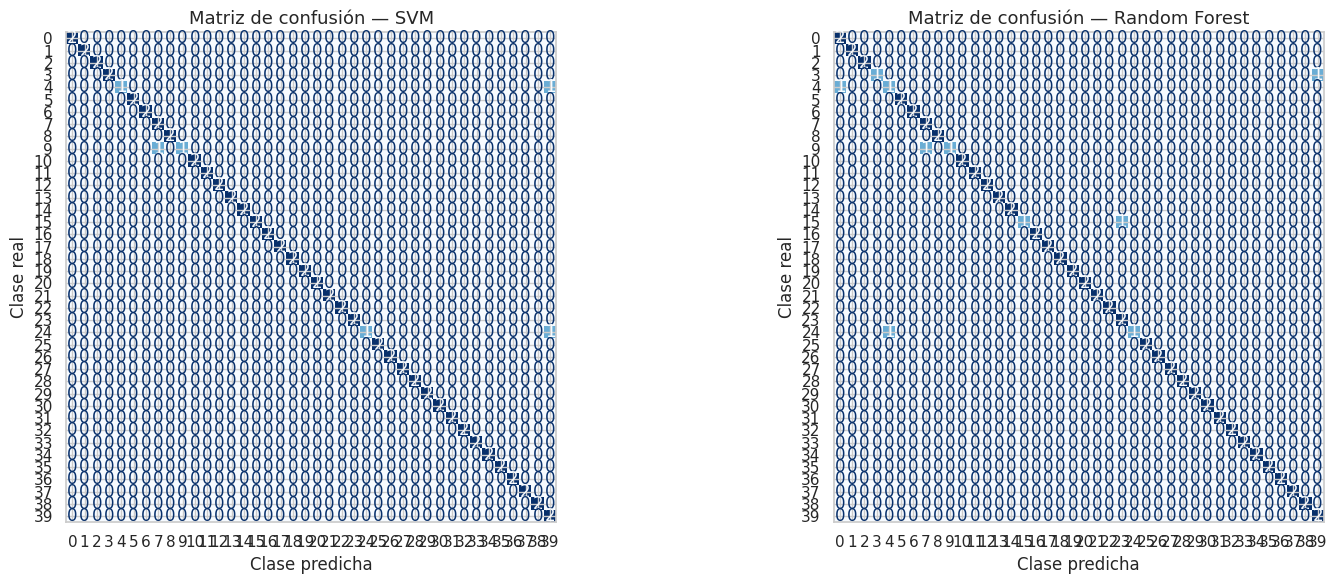

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, item in zip(axes, classic_models):
    y_pred = item["model"].predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"Matriz de confusión — {item['Modelo']}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")

plt.tight_layout()
plt.savefig("fig_ml_05_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.1 Importancia de píxeles en Random Forest

Random Forest permite estimar la importancia de cada característica. Como las características corresponden a píxeles, las importancias se reorganizan en una imagen 64 × 64.

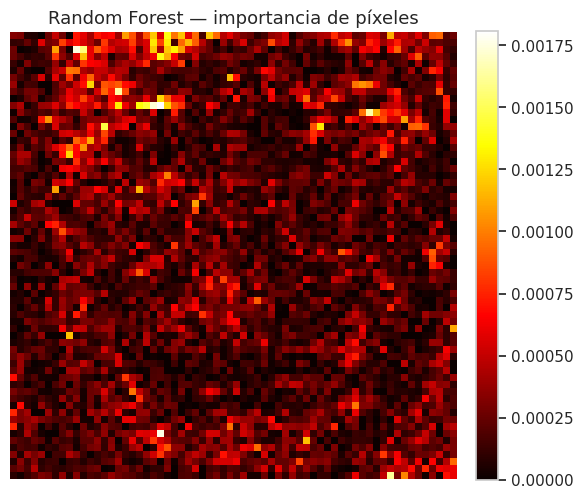

In [14]:
rf_importances = rf_model.feature_importances_.reshape(64, 64)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(rf_importances, cmap="hot", interpolation="nearest")
ax.set_title("Random Forest — importancia de píxeles")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("fig_ml_06_rf_pixel_importance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Comparación contra el MLP del taller RNA

La comparación final integra el mejor MLP del taller RNA y los dos modelos clásicos seleccionados. Se comparan métricas de prueba, validación, tiempo y brecha entre entrenamiento y prueba.

In [15]:
comparison_rows = [mlp_reference]
comparison_rows.extend(classic_summary.to_dict("records"))
comparison = pd.DataFrame(comparison_rows)

comparison["Gap Train-Test"] = comparison["Train Accuracy"] - comparison["Test Accuracy"]

ordered_cols = [
    "Modelo", "Familia", "Entrada", "Hiperparámetros",
    "Train Accuracy", "Val Accuracy", "Test Accuracy",
    "F1 Macro", "F1 Micro", "Precision Macro", "Recall Macro",
    "Gap Train-Test", "Tiempo (s)", "Parámetros/Árboles",
]

comparison = comparison[ordered_cols]
comparison_sorted = comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

display(comparison_sorted)

,Modelo,Familia,Entrada,Hiperparámetros,Train Accuracy,Val Accuracy,Test Accuracy,F1 Macro,F1 Micro,Precision Macro,Recall Macro,Gap Train-Test,Tiempo (s),Parámetros/Árboles
0,MLP RNA,Deep Learning,4096,"hidden=[512, 256], Adam, Dropout=0.40, L2=1e-5",1.0,0.9875,0.9750,0.973300,0.9750,0.983300,0.9750,0.0250,15.300000,"2,240,808 parámetros"
1,SVM,ML clásico,4096,"C=0.003, kernel=linear",1.0,0.9625,0.9625,0.961667,0.9625,0.979167,0.9625,0.0375,0.086291,vectores de soporte
2,Random Forest,ML clásico,4096,"max_depth=None, max_features=sqrt, min_samples...",1.0,0.9500,0.9375,0.934167,0.9375,0.954167,0.9375,0.0625,0.448068,200 árboles


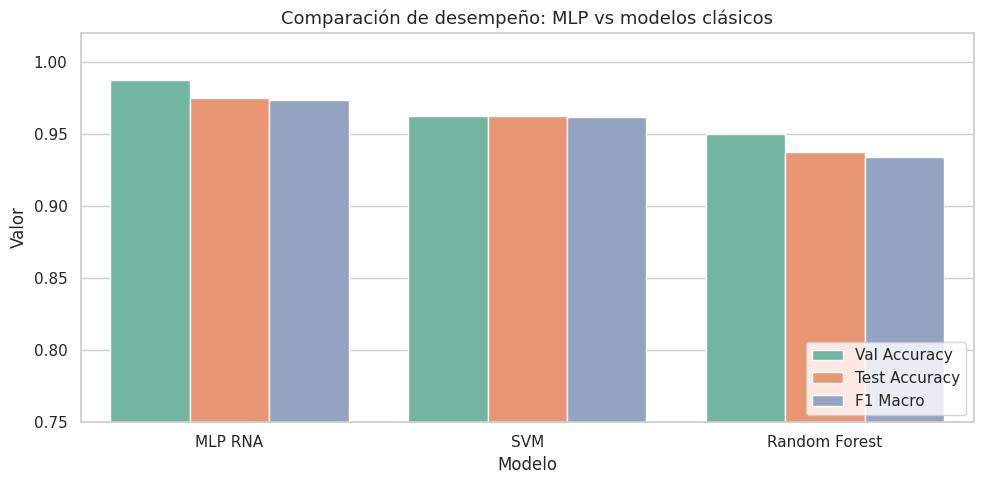

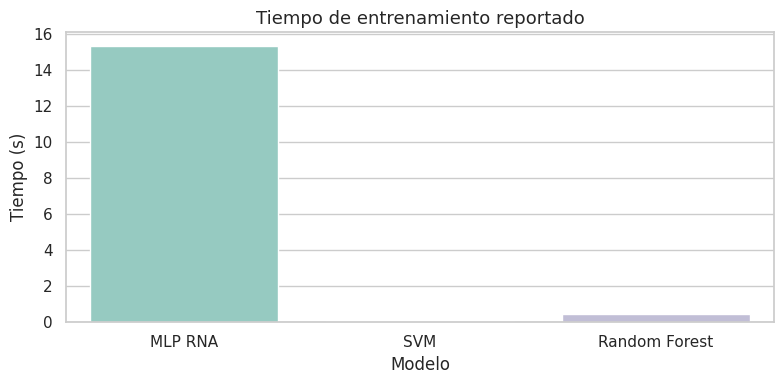

In [16]:
metric_plot = comparison.melt(
    id_vars=["Modelo"],
    value_vars=["Val Accuracy", "Test Accuracy", "F1 Macro"],
    var_name="Métrica",
    value_name="Valor",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metric_plot, x="Modelo", y="Valor", hue="Métrica", ax=ax, palette="Set2")
ax.set_ylim(0.75, 1.02)
ax.set_title("Comparación de desempeño: MLP vs modelos clásicos")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig_ml_07_model_comparison_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=comparison, x="Modelo", y="Tiempo (s)", ax=ax, palette="Set3")
ax.set_title("Tiempo de entrenamiento reportado")
ax.set_xlabel("Modelo")
ax.set_ylabel("Tiempo (s)")
plt.tight_layout()
plt.savefig("fig_ml_08_training_time.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 11. Análisis de sobreajuste y subajuste

Para identificar sobreajuste y subajuste se revisan dos señales:

- **Sobreajuste:** accuracy de entrenamiento muy alta y caída apreciable en validación o test.
- **Subajuste:** accuracy de entrenamiento y validación bajas, lo cual indica que el modelo no logra capturar la estructura del problema.

También se revisan configuraciones no seleccionadas de las búsquedas para observar casos representativos.

In [17]:
def classify_fit_case(train_acc, val_acc):
    gap = train_acc - val_acc
    if train_acc >= 0.95 and gap >= 0.08:
        return "Sobreajuste"
    if train_acc <= 0.80 and val_acc <= 0.80:
        return "Subajuste"
    return "Ajuste razonable"

all_trials = pd.concat([svm_search, rf_search], ignore_index=True)
all_trials["Diagnóstico"] = all_trials.apply(
    lambda row: classify_fit_case(row["Train Accuracy"], row["Val Accuracy"]),
    axis=1,
)

print("Diagnóstico de los modelos finales:")
final_fit = comparison[["Modelo", "Train Accuracy", "Val Accuracy", "Test Accuracy", "Gap Train-Test"]].copy()
final_fit["Diagnóstico"] = final_fit.apply(
    lambda row: classify_fit_case(row["Train Accuracy"], row["Val Accuracy"]),
    axis=1,
)
display(final_fit)

print("\nEjemplos de subajuste encontrados durante la búsqueda:")
underfit_examples = all_trials[all_trials["Diagnóstico"] == "Subajuste"].sort_values("Val Accuracy").head(5)
display(underfit_examples[["Modelo", "Train Accuracy", "Val Accuracy", "Val F1 Macro", "params", "Diagnóstico"]])

print("\nEjemplos de sobreajuste encontrados durante la búsqueda:")
overfit_examples = all_trials[all_trials["Diagnóstico"] == "Sobreajuste"].sort_values("Val Accuracy").head(5)
display(overfit_examples[["Modelo", "Train Accuracy", "Val Accuracy", "Val F1 Macro", "params", "Diagnóstico"]])

Diagnóstico de los modelos finales:


,Modelo,Train Accuracy,Val Accuracy,Test Accuracy,Gap Train-Test,Diagnóstico
0,MLP RNA,1.0,0.9875,0.9750,0.0250,Ajuste razonable
1,SVM,1.0,0.9625,0.9625,0.0375,Ajuste razonable
2,Random Forest,1.0,0.9500,0.9375,0.0625,Ajuste razonable



Ejemplos de subajuste encontrados durante la búsqueda:


,Modelo,Train Accuracy,Val Accuracy,Val F1 Macro,params,Diagnóstico



Ejemplos de sobreajuste encontrados durante la búsqueda:


,Modelo,Train Accuracy,Val Accuracy,Val F1 Macro,params,Diagnóstico
50,SVM,1.0,0.2750,0.326613,"{'C': 0.3, 'gamma': 0.01, 'kernel': 'rbf'}",Sobreajuste
49,SVM,1.0,0.2750,0.326613,"{'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}",Sobreajuste
45,SVM,1.0,0.3375,0.393421,"{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}",Sobreajuste
44,SVM,1.0,0.3375,0.393421,"{'C': 3, 'gamma': 0.01, 'kernel': 'rbf'}",Sobreajuste
48,SVM,1.0,0.3375,0.393421,"{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}",Sobreajuste


---
## 12. Discusión técnica

### 12.1 Limitaciones de modelos lineales

La SVM lineal aprende una frontera lineal en el espacio de características. En imágenes aplanadas, esto significa separar personas mediante combinaciones lineales de intensidades de píxeles. Si las diferencias entre personas requieren relaciones complejas entre regiones del rostro, una frontera lineal puede ser insuficiente.

La búsqueda también incluye SVM con kernel RBF, que permite fronteras no lineales mediante el truco del kernel. La comparación entre `linear` y `rbf` permite observar si la no linealidad mejora el desempeño en validación.

### 12.2 Impacto de la dimensionalidad

Cada imagen tiene 4096 características y el entrenamiento tiene 240 muestras. El ratio muestras/features es bajo, por lo que existe riesgo de sobreajuste. Esta condición afecta especialmente a modelos que dependen de distancias en alta dimensión o divisiones sobre píxeles individuales.

### 12.3 Capacidad de modelar no linealidades

- SVM lineal: frontera lineal.
- SVM RBF: frontera no lineal inducida por kernel.
- Random Forest: frontera no lineal por particiones sucesivas del espacio de características.
- MLP: composición de capas densas con activaciones no lineales.

### 12.4 Diferencias entre ML clásico y Deep Learning

Los modelos clásicos pueden funcionar muy bien con pocos datos y entrenamiento relativamente controlado. El MLP tiene mayor capacidad representacional, pero también más parámetros y mayor riesgo de sobreajuste. En Olivetti Faces, la cantidad de datos es pequeña, por lo que la regularización y la validación son determinantes.

In [18]:
best_overall = comparison_sorted.iloc[0]
best_classic = classic_summary.sort_values("Test Accuracy", ascending=False).iloc[0]
svm_kernel_best = svm_best_params["kernel"]

analysis_md = f"""
### 12.5 Conclusiones del experimento ejecutado

1. **Mejor modelo global:** el mejor resultado en test fue `{best_overall['Modelo']}` con accuracy `{best_overall['Test Accuracy']:.4f}` y F1 macro `{best_overall['F1 Macro']:.4f}`.

2. **Mejor modelo clásico:** entre los modelos clásicos, el mejor resultado en test fue `{best_classic['Modelo']}` con accuracy `{best_classic['Test Accuracy']:.4f}` y F1 macro `{best_classic['F1 Macro']:.4f}`.

3. **SVM:** la mejor configuración SVM usó kernel `{svm_kernel_best}`. Esto permite discutir directamente si el problema fue mejor resuelto por una frontera lineal o por una frontera no lineal con RBF.

4. **Random Forest:** el modelo alcanzó accuracy de test `{classic_summary.loc[classic_summary['Modelo'] == 'Random Forest', 'Test Accuracy'].iloc[0]:.4f}`. Aunque los árboles permiten no linealidades, trabajar con 4096 píxeles y solo 240 muestras de entrenamiento aumenta el riesgo de sobreajuste.

5. **Complejidad vs desempeño:** el MLP tiene muchos más parámetros entrenables, mientras que SVM y Random Forest son modelos clásicos más directos. Si el desempeño clásico se acerca al MLP, esto indica que para este dataset pequeño los modelos clásicos siguen siendo competitivos.

6. **Escenarios adecuados:** SVM es adecuado para datasets pequeños o medianos de alta dimensionalidad; Random Forest es útil cuando se busca un modelo no lineal con interpretabilidad por importancia de características; el MLP es preferible cuando se desea mayor capacidad de representación y se cuenta con regularización suficiente.
"""

display(Markdown(analysis_md))


### 12.5 Conclusiones del experimento ejecutado

1. **Mejor modelo global:** el mejor resultado en test fue `MLP RNA` con accuracy `0.9750` y F1 macro `0.9733`.

2. **Mejor modelo clásico:** entre los modelos clásicos, el mejor resultado en test fue `SVM` con accuracy `0.9625` y F1 macro `0.9617`.

3. **SVM:** la mejor configuración SVM usó kernel `linear`. Esto permite discutir directamente si el problema fue mejor resuelto por una frontera lineal o por una frontera no lineal con RBF.

4. **Random Forest:** el modelo alcanzó accuracy de test `0.9375`. Aunque los árboles permiten no linealidades, trabajar con 4096 píxeles y solo 240 muestras de entrenamiento aumenta el riesgo de sobreajuste.

5. **Complejidad vs desempeño:** el MLP tiene muchos más parámetros entrenables, mientras que SVM y Random Forest son modelos clásicos más directos. Si el desempeño clásico se acerca al MLP, esto indica que para este dataset pequeño los modelos clásicos siguen siendo competitivos.

6. **Escenarios adecuados:** SVM es adecuado para datasets pequeños o medianos de alta dimensionalidad; Random Forest es útil cuando se busca un modelo no lineal con interpretabilidad por importancia de características; el MLP es preferible cuando se desea mayor capacidad de representación y se cuenta con regularización suficiente.


---
## 13. Resumen de entregables cubiertos

| Requerimiento del taller | Evidencia en el notebook |
|---|---|
| Código reproducible | Semilla fija, partición estratificada y búsqueda explícita |
| Implementación de modelos clásicos | SVM y Random Forest |
| Mismo conjunto de entrenamiento | Split 60/20/20 reutilizado para todos los modelos |
| Mismas características de entrada | 4096 píxeles normalizados para ambos modelos |
| Ajuste de hiperparámetros | Búsqueda manual sobre validación para SVM y Random Forest |
| Misma validación | Selección por `X_val_sc`, `y_val` |
| Comparación con MLP | Tabla final MLP vs SVM vs Random Forest |
| Tablas y gráficas | Búsquedas, métricas, matrices de confusión, tiempos, importancia de píxeles |
| Conclusiones técnicas | Discusión sobre linealidad, dimensionalidad, sobreajuste y complejidad |